In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read data and overview

In [2]:
df=pd.read_csv(r"C:\Users\b.k\Colab Notebooks\Dataset\car_sales_data.csv")
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [3]:
df.describe().head()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [5]:
df.nunique()

Manufacturer               5
Model                     15
Engine size               14
Fuel type                  3
Year of manufacture       39
Mileage                44971
Price                  25045
dtype: int64

In [6]:
df.shape

(50000, 7)

In [7]:
for i in df.columns:
  print(df[i].value_counts())
  print("----------------------------------------------------------------------------------------------------------------")

Manufacturer
Ford       14959
VW         14913
Toyota     12554
BMW         4965
Porsche     2609
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------
Model
Mondeo        5058
Golf          5050
Polo          4992
Focus         4976
Fiesta        4925
Passat        4871
RAV4          4292
Prius         4171
Yaris         4091
Z4            1688
M5            1645
X3            1632
911            872
Cayenne        870
718 Cayman     867
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------
Engine size
1.4    10060
2.0     7631
1.8     7032
1.0     6343
1.6     5509
1.2     4984
2.4     2364
2.2     1678
3.0     1368
4.0     1092
4.4      559
5.0      525
2.6      448
3.5      407
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------


# Data analysis + EDA

In [8]:
# missing values
print(df.isnull().sum(),"\n")

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64 



In [9]:
# duplicated values
print(df.duplicated().sum())
# delete duplicated
df.drop_duplicates(inplace=True)

12


In [10]:
# outliers
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print(40 * "-")

Column: Engine size
Number of outliers: 3951
----------------------------------------
Column: Year of manufacture
Number of outliers: 0
----------------------------------------
Column: Mileage
Number of outliers: 385
----------------------------------------
Column: Price
Number of outliers: 2649
----------------------------------------


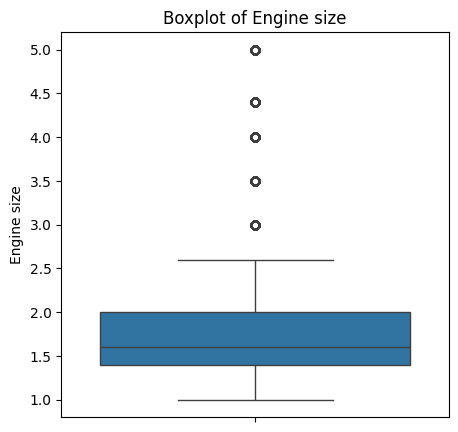

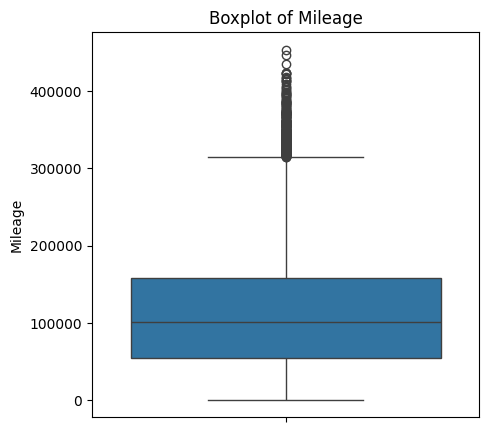

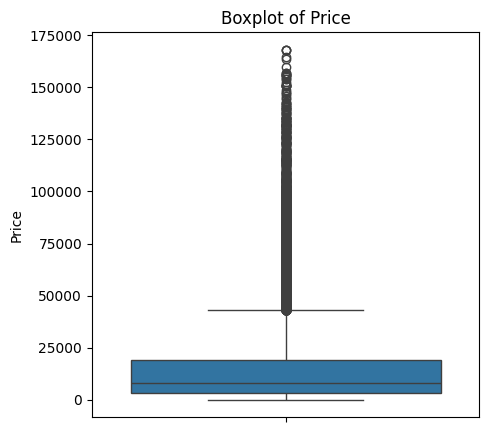

In [11]:
numeric_cols=pd.DataFrame(df.select_dtypes(include=np.number))
for col in numeric_cols:
  if col=="Year of manufacture":
    continue
  plt.figure(figsize=(5, 5))
  sns.boxplot(numeric_cols[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

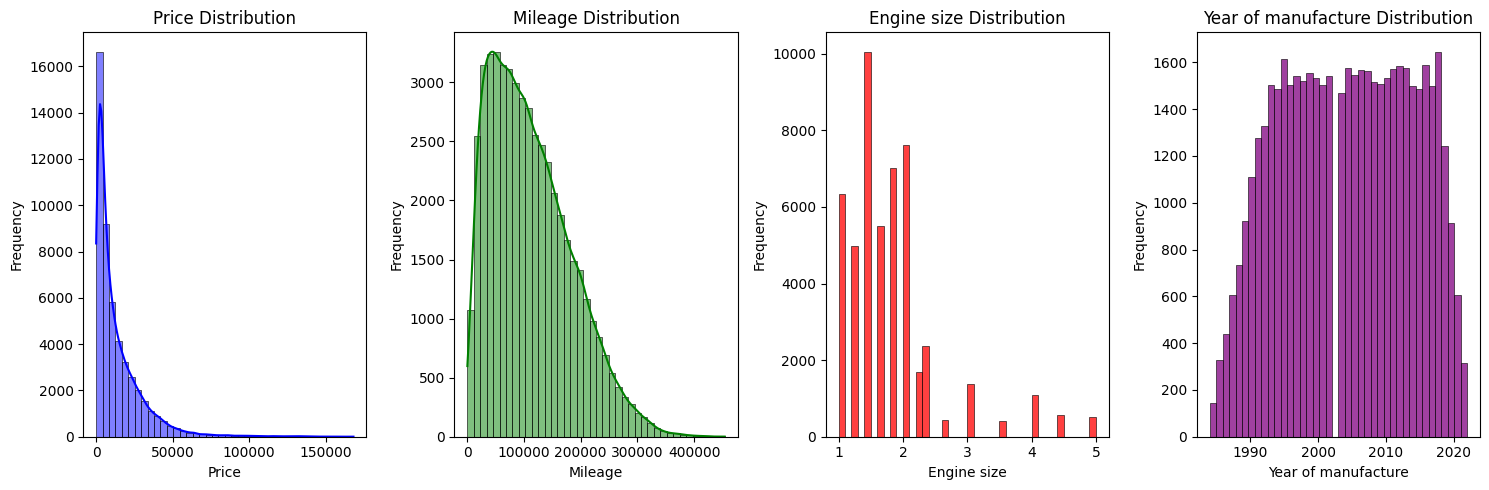

In [12]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 4, 1)
sns.histplot(df["Price"], bins=40, kde=True, color="blue",edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")


plt.subplot(1, 4, 2)
sns.histplot(df["Mileage"], bins=40, kde=True, color="green",edgecolor="black")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.title("Mileage Distribution")

plt.subplot(1, 4, 3)
sns.histplot(df["Engine size"], bins=40, color="red",edgecolor="black")
plt.xlabel("Engine size")
plt.ylabel("Frequency")
plt.title("Engine size Distribution")

plt.subplot(1, 4, 4)
sns.histplot(df["Year of manufacture"], bins=40,  color="purple",edgecolor="black")
plt.xlabel("Year of manufacture")
plt.ylabel("Frequency")
plt.title("Year of manufacture Distribution")



plt.tight_layout()
plt.savefig("figures_png.png", dpi=300)
plt.show()


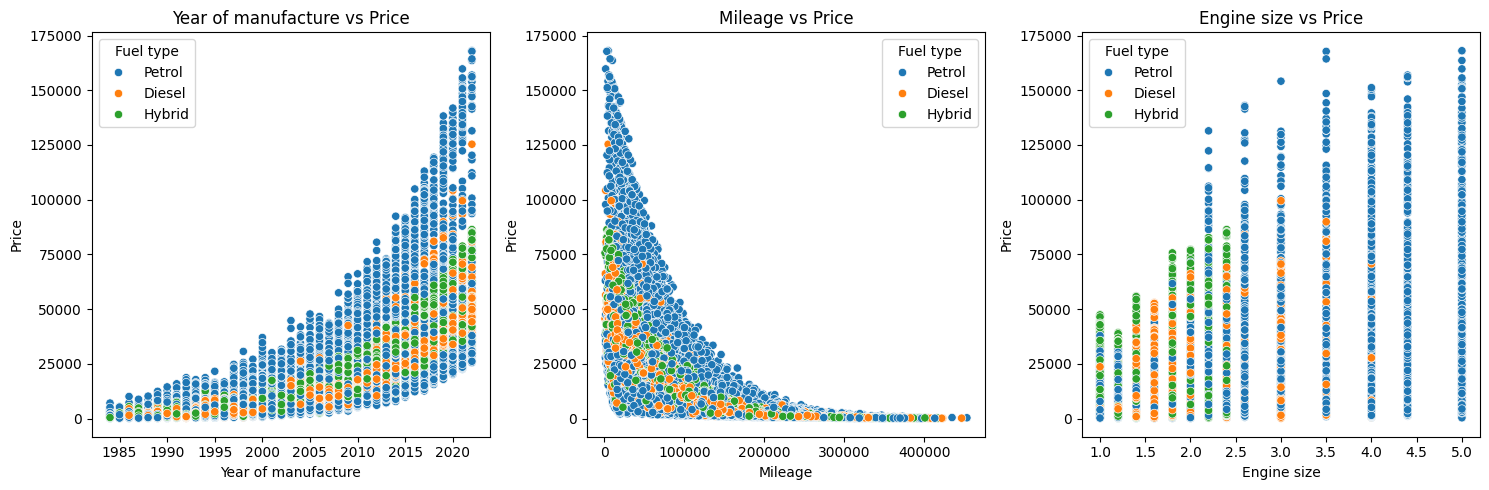

In [13]:
model_df=df[["Year of manufacture","Mileage","Engine size","Price","Fuel type"]]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x="Year of manufacture",y="Price",data=model_df,hue='Fuel type')
plt.xlabel("Year of manufacture")
plt.ylabel("Price")
plt.title("Year of manufacture vs Price")

plt.subplot(1, 3, 2)
sns.scatterplot(x="Mileage",y="Price",data=model_df,hue='Fuel type')
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")

plt.subplot(1, 3, 3)
sns.scatterplot(x="Engine size",y="Price",data=model_df,hue='Fuel type')
plt.xlabel("Engine size")
plt.ylabel("Price")
plt.title("Engine size vs Price")


plt.tight_layout()
plt.savefig("figures_png.png", dpi=300)
plt.show()


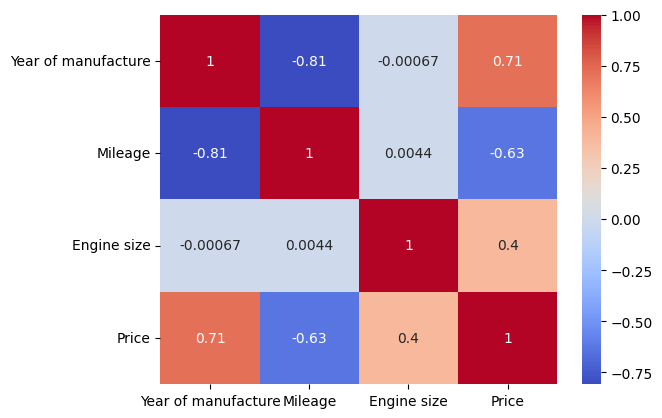

In [14]:
# corlation matrix
umeric_model_df = model_df.select_dtypes(include="number")
corr = umeric_model_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.savefig("figures_png.png", dpi=300)
plt.show()


# bulding prediction model

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
X = df[["Year of manufacture", "Mileage","Engine size"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results.head()

Mean Absolute Error: 2285.58
Mean Squared Error: 19435091.14
Root Mean Squared Error: 4408.52
R² Score: 0.9282


,Actual,Predicted
27762,28636,28305.02
44543,59783,48291.50
32350,14865,17042.44
6706,2219,3762.00
20260,1001,1287.31


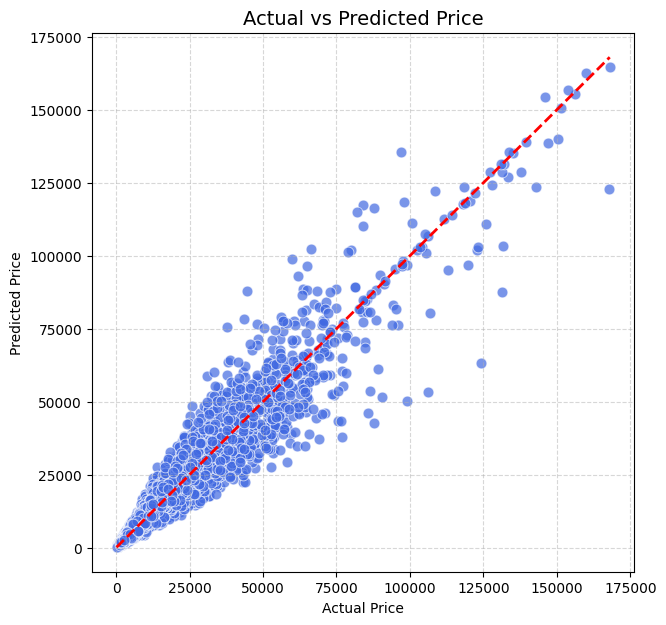

In [17]:
plt.figure(figsize=(7,7))
sns.scatterplot(x="Actual", y="Predicted", data=results, color="royalblue", s=60, alpha=0.7)

plt.plot([results.min().min(), results.max().max()],
         [results.min().min(), results.max().max()],
         color='red', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Price", fontsize=14)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("figures_png.png", dpi=300)
plt.show()


In [18]:
import joblib

joblib.dump(model,'car_price_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']